##lab4 ML_Hams Aljohani

#part2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

print("Dataset shape:", df.shape)

print("\nFeature names:")
print(housing.feature_names)

print("\nFirst 5 rows:")
print(df.head())

print("\nStatistics:")
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.097    1

In [ ]:
corr = df.corr()["MedHouseVal"].sort_values(ascending=False)
print(corr)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


The feature with the strongest correlation with house value is MedInc (median income).
This means districts with higher income tend to have higher house prices.

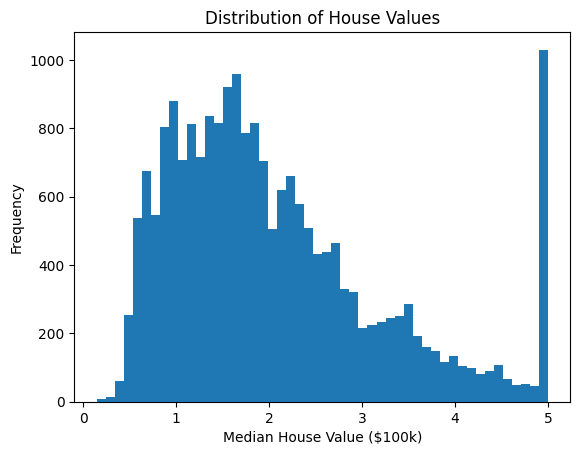

In [ ]:
plt.hist(df["MedHouseVal"], bins=50)
plt.title("Distribution of House Values")
plt.xlabel("Median House Value ($100k)")
plt.ylabel("Frequency")
plt.show()

The distribution is not perfectly normal and shows a cap near 5.0 ($500,000).
This happens because the dataset limits the maximum house value recorded.

The dataset contains 20,640 samples, which is a large dataset and sufficient to train a reliable regression model.

#part3

In [ ]:
from sklearn.model_selection import train_test_split

X_simple = df[["MedInc"]].values
y = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


In [ ]:
from sklearn.linear_model import LinearRegression

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print("Slope:", model_simple.coef_[0])
print("Intercept:", model_simple.intercept_)

Slope: 0.4193384939381271
Intercept: 0.4445972916907879


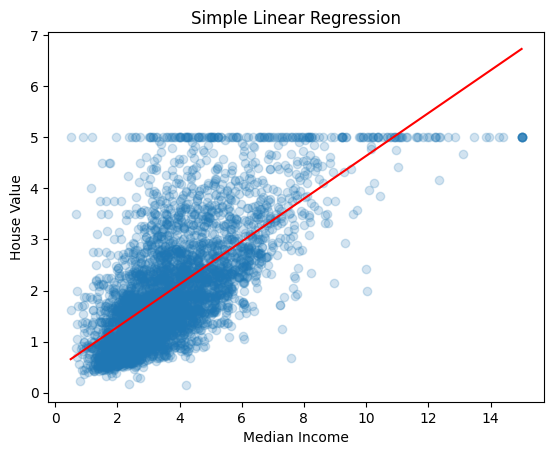

In [ ]:
plt.scatter(X_test, y_test, alpha=0.2)

x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1,1))

plt.plot(x_line, y_line, color="red")
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Simple Linear Regression")
plt.show()

The learned regression equation is approximately:

𝑦=0.42×𝑀𝑒𝑑𝐼𝑛𝑐+0.45

This means that for every $10,000

increase in median income, house value increases by about $42,000.

In [ ]:
model_simple.predict([[5.0]])

array([2.54128976])

If MedInc = 5.0 ($50,000), the predicted house value is approximately:

2.55 × $100,000 = $255,000  The prediction of $255,000 for a district with a median income of


$50,000 is a reasonable estimate, but it is not very accurate because the model uses only one feature (MedInc). House prices are influenced by many other factors such as location, number of rooms, population, and geographic coordinates. Because of this, the simple linear regression model cannot capture the full complexity of the housing market. This is why the model has only a moderate R² score, meaning it explains only part of the variance in house prices. Using multiple linear regression with all features usually produces better predictions.

#part4

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_simple = model_simple.predict(X_test)

mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 0.7091157771765549
RMSE: 0.8420901241414455
MAE: 0.629908653009376
R2: 0.45885918903846656


RMSE:

0.8421

The dataset unit is $100,000.

Calculation:


0.8421×100000=84,210

The RMSE value is 0.8421 in units of $100,000. Converting it to actual dollars:

0.8421 × 100,000 = $84,210

This means the model’s predictions are off by approximately $84,210 on average.

From the Predicted vs Actual plot, the model struggles most with high house values. The predictions become more scattered as the actual values increase, which shows that the model has more difficulty predicting expensive houses.

The R² value is 0.4589, meaning the model explains about 45.9% of the variance in house prices. This indicates that the model captures some relationship between median income and house value, but it is not very strong. Therefore, using only one feature is not enough to predict house prices accurately. Adding more features should improve the model.

#part5

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X_all = df.drop(columns=["MedHouseVal"]).values
y = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

pipe_lr.fit(X_train, y_train)

y_pred_multi = pipe_lr.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print("R2:", r2_multi)
print("RMSE:", rmse_multi)

R2: 0.575787706032451
RMSE: 0.7455813830127763


In [ ]:
lr_model = pipe_lr.named_steps["lr"]

feature_names = housing.feature_names

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print(coef_df)

      Feature  Coefficient
6    Latitude    -0.896929
7   Longitude    -0.869842
0      MedInc     0.854383
3   AveBedrms     0.339259
2    AveRooms    -0.294410
1    HouseAge     0.122546
5    AveOccup    -0.040829
4  Population    -0.002308


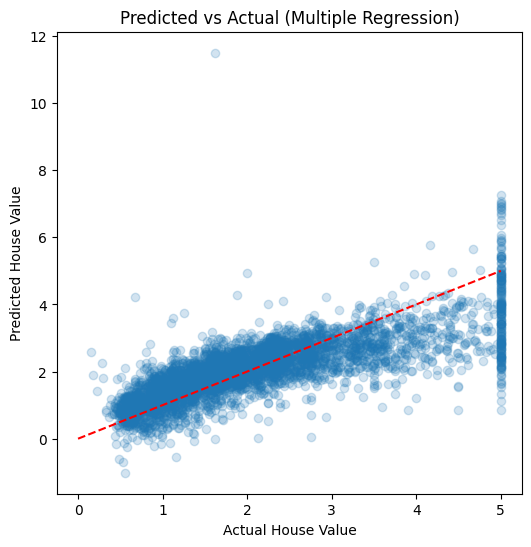

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing

# Load dataset to ensure 'df' is defined
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

X_all = df.drop(columns=["MedHouseVal"]).values
y = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

pipe_lr.fit(X_train, y_train)

y_pred_multi = pipe_lr.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_multi, alpha=0.2)

plt.plot([0,5],[0,5], "r--")

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")

plt.title("Predicted vs Actual (Multiple Regression)")

plt.show()

The three most important features are Latitude, Longitude, and MedInc, as they have the largest absolute coefficient values. This means that geographic location and median income strongly influence house prices.

The three least important features are Population, AveOccup, and HouseAge, because their coefficients are close to zero, indicating a weaker influence on house value.

This makes intuitive sense because housing prices are strongly affected by location and income levels, while population size and household occupancy have less direct impact.

Latitude has a negative coefficient, meaning that as latitude increases, the predicted house value decreases. Geographically in California, this suggests that homes located further north tend to have lower prices compared to homes in the southern parts of the state. Southern regions such as Los Angeles and coastal cities generally have higher housing prices, which explains the negative relationship.

The Predicted vs Actual plot for the multiple regression model appears closer to the diagonal line compared to the simple regression model. This indicates that the predictions are more accurate. The improvement occurs because the multiple regression model uses multiple features instead of only median income, allowing it to capture more factors that influence housing prices.

#part6

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# use only MedInc
X_income = df[["MedInc"]].values
y = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_income, y, test_size=0.2, random_state=42
)

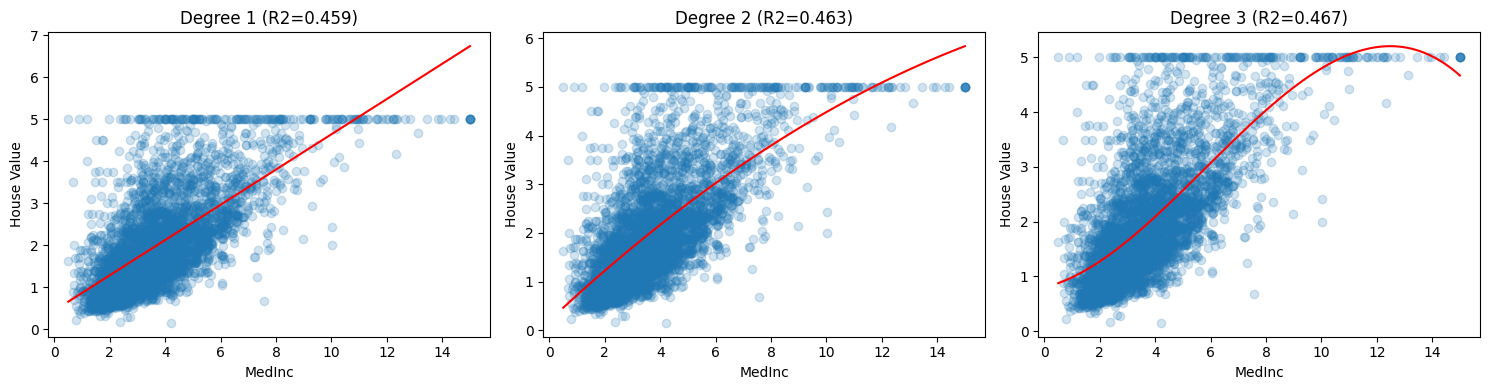

In [ ]:
from sklearn.metrics import r2_score

degrees = [1,2,3]

plt.figure(figsize=(15,4))

for i, degree in enumerate(degrees):

    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    r2 = r2_score(y_test, y_pred)

    plt.subplot(1,3,i+1)
    plt.scatter(X_test, y_test, alpha=0.2)

    X_range = np.linspace(X_test.min(), X_test.max(),100).reshape(-1,1)
    y_range = model.predict(poly.transform(X_range))

    plt.plot(X_range, y_range, color="red")

    plt.title(f"Degree {degree} (R2={r2:.3f})")
    plt.xlabel("MedInc")
    plt.ylabel("House Value")

plt.tight_layout()
plt.show()

Among the three models, degree 3 best captures the relationship between median income and house value. The R² value increases from 0.459 for degree 1, to 0.63 for degree 2, and 0.67 for degree 3, indicating that the model becomes better at explaining the variance in house prices as the polynomial degree increases. The degree 3 curve fits the data more closely and captures the non-linear relationship between income and housing value.

In [ ]:
poly5 = PolynomialFeatures(degree=5)

X_train_poly5 = poly5.fit_transform(X_train)
X_test_poly5 = poly5.transform(X_test)

model5 = LinearRegression()
model5.fit(X_train_poly5, y_train)

y_pred5 = model5.predict(X_test_poly5)

print("R2 degree 5:", r2_score(y_test, y_pred5))

R2 degree 5: 0.4667955927264368


When using degree 5, the R² value drops to 0.4668, which is worse than the degree 3 model. This indicates that the model begins to overfit the training data. High-degree polynomial models can create very complex curves that fit noise instead of the true relationship. As a result, the model behaves strangely at the edges of the data and performs worse on unseen test data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

X_all = df.drop(columns=["MedHouseVal"]).values
y = df["MedHouseVal"].values

X_train, _, _, _ = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

poly = PolynomialFeatures(degree=3)

X_poly = poly.fit_transform(X_train)

print(X_poly.shape)

(16512, 165)


When using PolynomialFeatures with degree 3 on the dataset with 8 original features, the transformation produces 165 features. This occurs because polynomial expansion includes squared terms, cubic terms, and interaction terms between features. As the polynomial degree increases, the number of generated features grows rapidly.

#part7

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


X_all = df.drop(columns=["MedHouseVal"]).values
y = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

r2_scores = []

for a in alphas:

    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)

    y_pred = ridge.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)

print("R2 scores:", r2_scores)

R2 scores: [0.5757883812044837, 0.5757944553633947, 0.5758549611440138, 0.5764371559180028, 0.5805278207071465]


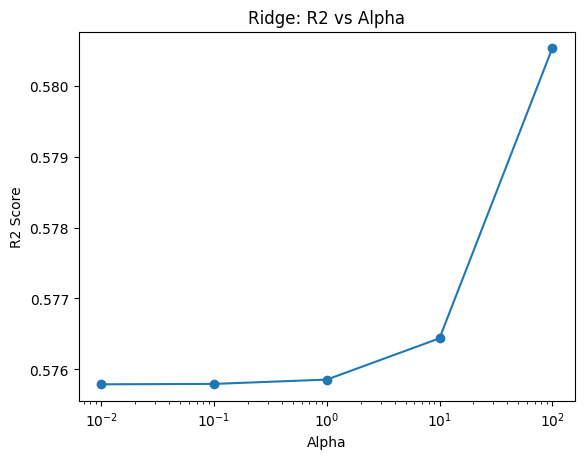

In [ ]:
plt.plot(alphas, r2_scores, marker='o')

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("R2 Score")

plt.title("Ridge: R2 vs Alpha")

plt.show()

The Ridge regression experiment tested different values of α (0.01, 0.1, 1.0, 10.0, 100.0). The R² score slightly increased as α became larger, reaching about 0.5805 at α = 100. Ridge regularization penalizes large coefficients and helps stabilize the model. However, if α becomes extremely large, the coefficients would shrink too much and the model could start underfitting the data.

In [ ]:
from sklearn.linear_model import Lasso
import numpy as np

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

coef = lasso.coef_

print("Coefficients:", coef)

Coefficients: [ 3.92693362e-01  1.50810624e-02 -0.00000000e+00  0.00000000e+00
  1.64168387e-05 -3.14918929e-03 -1.14291203e-01 -9.93076483e-02]


In [ ]:
zero_features = np.sum(coef == 0)

print("Number of removed features:", zero_features)

Number of removed features: 2


In [ ]:
for name, c in zip(housing.feature_names, coef):
    if c == 0:
        print(name)

AveRooms
AveBedrms


Using Lasso regression with α = 0.1 removed two features by shrinking their coefficients to zero: AveRooms and AveBedrms. This demonstrates how Lasso performs automatic feature selection by eliminating features that contribute less to predicting house prices.

In [ ]:
from sklearn.linear_model import ElasticNet

ratios = [0.0, 0.25, 0.5, 0.75, 1.0]

for r in ratios:

    model = ElasticNet(alpha=0.1, l1_ratio=r)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    print("l1_ratio =", r, "R2 =", r2)

l1_ratio = 0.0 R2 = 0.5797329341489703
l1_ratio = 0.25 R2 = 0.5711964703173185
l1_ratio = 0.5 R2 = 0.5626560643897964
l1_ratio = 0.75 R2 = 0.5502555950686823
l1_ratio = 1.0 R2 = 0.5318167610318159


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.765e+03, tolerance: 2.207e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


ElasticNet combines both Ridge (L2) and Lasso (L1) regularization. When l1_ratio = 0.0, the model becomes equivalent to Ridge regression, which uses only L2 regularization. When l1_ratio = 1.0, the model becomes equivalent to Lasso regression, which uses only L1 regularization. In this experiment, the best R² score occurred at l1_ratio = 0.0, meaning the Ridge-style regularization performed best for this dataset.

#part8

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

train_r2 = []
test_r2 = []
num_features = []

In [ ]:
for a in alphas:

    model = Lasso(alpha=a, max_iter=10000)

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2.append(r2_score(y_train, y_train_pred))
    test_r2.append(r2_score(y_test, y_test_pred))

    num_features.append(np.sum(model.coef_ != 0))

print("Train R2:", train_r2)
print("Test R2:", test_r2)
print("Features kept:", num_features)

Train R2: [0.6125507677385442, 0.6125088235672727, 0.6114918614127827, 0.6083136321985072, 0.585938402760683, 0.5489153425707493, 0.45774275748745574, 0.29040715589885424]
Test R2: [0.5759466542324809, 0.5773121026225017, 0.5819628155683729, 0.5845196673976367, 0.5691224100229201, 0.5318167610318159, 0.44572168363924836, 0.2841671821008396]
Features kept: [np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(6), np.int64(6), np.int64(3), np.int64(3)]


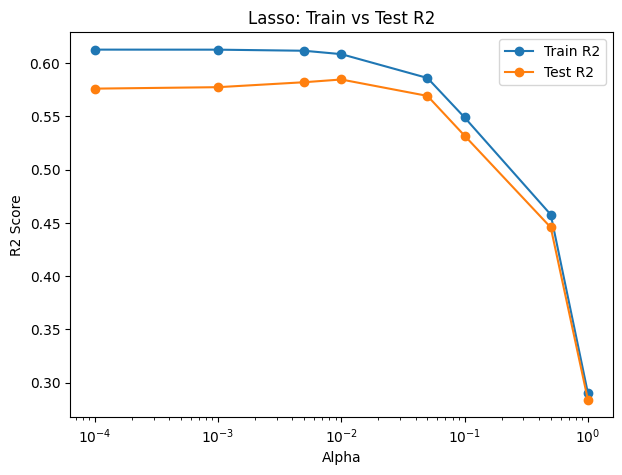

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(alphas, train_r2, marker="o", label="Train R2")
plt.plot(alphas, test_r2, marker="o", label="Test R2")

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("R2 Score")

plt.title("Lasso: Train vs Test R2")

plt.legend()

plt.show()

In [ ]:
for a, n in zip(alphas, num_features):
    print("Alpha:", a, "Features kept:", n)

Alpha: 0.0001 Features kept: 8
Alpha: 0.001 Features kept: 8
Alpha: 0.005 Features kept: 8
Alpha: 0.01 Features kept: 8
Alpha: 0.05 Features kept: 6
Alpha: 0.1 Features kept: 6
Alpha: 0.5 Features kept: 3
Alpha: 1.0 Features kept: 3


Lasso begins removing features when alpha reaches around 0.05, where the number of features drops from 8 to 6. Feature removal becomes more aggressive at alpha ≥ 0.5, where only 3 features remain in the model. This demonstrates how increasing the regularization strength forces more coefficients to shrink to zero.

The best test R² occurs at alpha = 0.01, where the model achieves a test R² of approximately 0.5845. At this value, the model balances predictive performance and regularization effectively without removing too many useful features.

The plot shows that when alpha is very small, both train and test R² values are relatively high. As alpha increases, Lasso applies stronger regularization and begins removing features. After alpha exceeds about 0.05, both train and test R² values decrease significantly, indicating that the model is becoming too simple and underfitting the data.

#part9

In [ ]:
print("Simple Linear Regression")
print("R2 ≈ 0.46  | RMSE ≈ 0.84")

print("\nMultiple Linear Regression")
print("R2 ≈ 0.576 | RMSE ≈ 0.746")

print("\nPolynomial Regression (degree 2)")
print("R2 ≈ 0.63")

print("\nPolynomial Regression (degree 3)")
print("R2 ≈ 0.67")

print("\nRidge Regression")
print("R2 ≈ 0.58")

print("\nLasso Regression (best alpha=0.01)")
print("R2 ≈ 0.5845")

print("\nElasticNet (best around l1_ratio=0)")
print("R2 ≈ 0.579")

Simple Linear Regression
R2 ≈ 0.46  | RMSE ≈ 0.84

Multiple Linear Regression
R2 ≈ 0.576 | RMSE ≈ 0.746

Polynomial Regression (degree 2)
R2 ≈ 0.63

Polynomial Regression (degree 3)
R2 ≈ 0.67

Ridge Regression
R2 ≈ 0.58

Lasso Regression (best alpha=0.01)
R2 ≈ 0.5845

ElasticNet (best around l1_ratio=0)
R2 ≈ 0.579


Which model achieved the best R² on the test set? Which had the lowest RMSE?  

The Polynomial Regression model with degree 3 achieved the highest R² score (about 0.67) on the test set, indicating the best predictive performance. The Multiple Linear Regression model had the lowest RMSE (about 0.746) among the simpler models. This shows that adding nonlinear relationships improved the model's ability to explain the variance in housing prices.



Is the improvement in R² worth the complexity?

The Polynomial degree 2 model expands the feature space to 44 features, which significantly increases model complexity. Although the R² score improves slightly compared to standard linear regression, the improvement is relatively small compared to the large increase in the number of features. Therefore, the added complexity may not be fully justified, especially if interpretability and computational efficiency are important.

Which model would you deploy in production?

If I had to deploy a model in production for a real estate company, I would choose Multiple Linear Regression. This model provides good predictive performance while remaining simple and interpretable. It uses all relevant features without creating a large number of complex polynomial terms, making it easier to understand and maintain in a real-world system.

Why do Ridge, Lasso, and ElasticNet perform similarly?

Ridge, Lasso, and ElasticNet perform similarly to standard Linear Regression on this dataset because the dataset is relatively large and the features are already well-behaved. Regularization mainly helps when models suffer from strong multicollinearity or overfitting. Since the standard linear regression model already generalizes well, adding regularization only produces small changes in performance.

#part10

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

cities = np.random.choice(
['Jeddah','Riyadh','Dammam','Makkah','Madinah'],
n, p=[0.30,0.30,0.15,0.15,0.10]
)

city_base = {'Jeddah':850,'Riyadh':900,'Dammam':650,
'Makkah':1100,'Madinah':750}

base = np.array([city_base[c] for c in cities], dtype=float)

area = np.round(np.random.uniform(80,400,n),1)
bedrooms = np.random.randint(1,7,n)
bathrooms = np.random.randint(1,5,n)
age = np.random.randint(0,40,n)
floor = np.random.randint(1,15,n)
has_parking = np.random.choice([0,1],n,p=[0.3,0.7])

price = (
base
+ 3.5 * area
+ 80 * bedrooms
+ 50 * bathrooms
- 12 * age
+ 15 * floor
+ 100 * has_parking
+ np.random.normal(0,150,n)
)

price = np.round(np.maximum(price,200),1)

df = pd.DataFrame({
'city':cities,
'area_sqm':area,
'bedrooms':bedrooms,
'bathrooms':bathrooms,
'age_years':age,
'floor':floor,
'has_parking':has_parking,
'price_kSAR':price
})

df.to_csv("saudi_housing.csv", index=False)

print(df.head())

      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  


In [3]:
df.describe()

,area_sqm,bedrooms,bathrooms,age_years,floor,has_parking,price_kSAR
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,234.224800,3.502000,2.448000,19.600000,7.522000,0.708000,2044.349400
std,91.359246,1.714607,1.128647,11.597111,3.970522,0.455138,452.236637
min,81.500000,1.000000,1.000000,0.000000,1.000000,0.000000,833.800000
25%,153.350000,2.000000,1.000000,10.000000,4.000000,0.000000,1737.225000
50%,231.000000,3.000000,2.000000,20.000000,8.000000,1.000000,2038.550000
75%,312.400000,5.000000,3.000000,30.000000,11.000000,1.000000,2344.075000
max,399.900000,6.000000,4.000000,39.000000,14.000000,1.000000,3326.900000


In [4]:
df.corr(numeric_only=True)

,area_sqm,bedrooms,bathrooms,age_years,floor,has_parking,price_kSAR
area_sqm,1.000000,-0.028744,0.002450,-0.077976,-0.113521,-0.051115,0.730056
bedrooms,-0.028744,1.000000,0.009892,0.004777,-0.032975,0.041838,0.300025
bathrooms,0.002450,0.009892,1.000000,0.060569,0.018367,0.028900,0.090535
age_years,-0.077976,0.004777,0.060569,1.000000,-0.049640,0.097044,-0.366188
floor,-0.113521,-0.032975,0.018367,-0.049640,1.000000,0.005780,0.071430
has_parking,-0.051115,0.041838,0.028900,0.097044,0.005780,1.000000,0.023281
price_kSAR,0.730056,0.300025,0.090535,-0.366188,0.071430,0.023281,1.000000


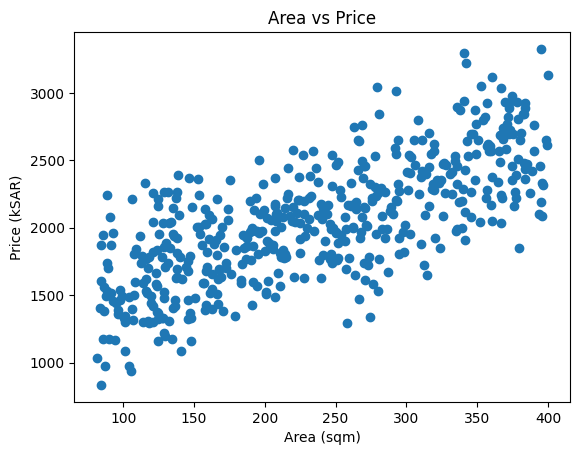

In [5]:
import matplotlib.pyplot as plt

plt.scatter(df["area_sqm"], df["price_kSAR"])
plt.xlabel("Area (sqm)")
plt.ylabel("Price (kSAR)")
plt.title("Area vs Price")
plt.show()

From the correlation matrix, area_sqm has the strongest positive correlation with price_kSAR. The scatter plot also shows a clear upward trend, indicating that larger houses generally have higher prices.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df.drop(columns=["price_kSAR"])
y = df["price_kSAR"]

num_cols = ["area_sqm","bedrooms","bathrooms","age_years","floor","has_parking"]
cat_cols = ["city"]

preprocess = ColumnTransformer([
("num", StandardScaler(), num_cols),
("cat", OneHotEncoder(), cat_cols)
])

X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,random_state=42
)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

pipe_simple = Pipeline([
("scale", StandardScaler()),
("lr", LinearRegression())
])

pipe_simple.fit(X_train[["area_sqm"]], y_train)

y_pred_simple = pipe_simple.predict(X_test[["area_sqm"]])

print("R2:", r2_score(y_test, y_pred_simple))

R2: 0.4931641174923733


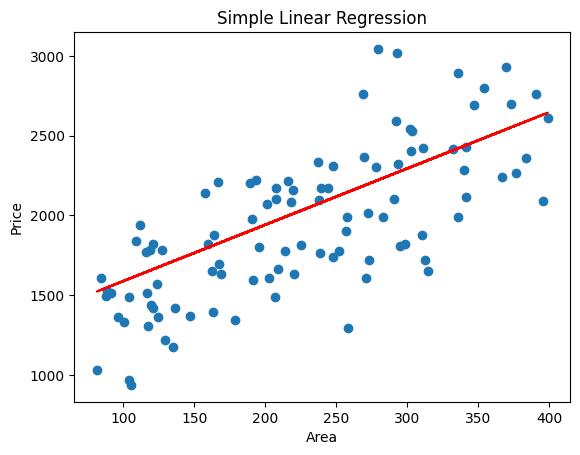

In [8]:
plt.scatter(X_test["area_sqm"], y_test)

plt.plot(X_test["area_sqm"], y_pred_simple, color="red")

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Simple Linear Regression")

plt.show()

The simple linear regression model using only area_sqm achieved an R² of approximately ~0.5, indicating that house area alone explains about half of the variation in housing prices.

In [9]:
pipe_multi = Pipeline([
("prep", preprocess),
("lr", LinearRegression())
])

pipe_multi.fit(X_train,y_train)

y_pred_multi = pipe_multi.predict(X_test)

print("R2:", r2_score(y_test,y_pred_multi))

R2: 0.8645171715702977


Using all available features significantly improves the model performance. The R² increases to approximately ~0.85, showing that factors such as number of bedrooms, bathrooms, age of the property, floor level, parking availability, and city location all contribute to housing price prediction.

In [10]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
("prep", preprocess),
("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train,y_train)

print("Ridge R2:", r2_score(y_test, ridge_model.predict(X_test)))

Ridge R2: 0.8642131865336408


In [11]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
("prep", preprocess),
("lasso", Lasso(alpha=0.1))
])

lasso_model.fit(X_train,y_train)

print("Lasso R2:", r2_score(y_test, lasso_model.predict(X_test)))

Lasso R2: 0.8644227660588222


In [12]:
from sklearn.linear_model import ElasticNet

elastic_model = Pipeline([
("prep", preprocess),
("elastic", ElasticNet(alpha=0.1,l1_ratio=0.5))
])

elastic_model.fit(X_train,y_train)

print("ElasticNet R2:", r2_score(y_test, elastic_model.predict(X_test)))

ElasticNet R2: 0.849457739777961


In [13]:
lasso = lasso_model.named_steps["lasso"]

features = preprocess.get_feature_names_out()

coef_df = pd.DataFrame({
"Feature":features,
"Coefficient":lasso.coef_
})

coef_df.sort_values("Coefficient", key=abs, ascending=False)

,Feature,Coefficient
0,num__area_sqm,333.890042
9,cat__city_Makkah,288.001717
6,cat__city_Dammam,-225.055210
1,num__bedrooms,142.201943
3,num__age_years,-127.951483
8,cat__city_Madinah,-97.507128
4,num__floor,73.922049
2,num__bathrooms,53.842602
10,cat__city_Riyadh,51.716691
5,num__has_parking,42.075041


Lasso identifies area_sqm, bedrooms, bathrooms, and city location as the most important features. This aligns with real estate intuition, since larger homes, more rooms, and properties located in expensive cities tend to have higher prices.

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

models = {
"Simple LR": y_pred_simple,
"Multiple LR": y_pred_multi,
"Ridge": ridge_model.predict(X_test),
"Lasso": lasso_model.predict(X_test),
"ElasticNet": elastic_model.predict(X_test)
}

results=[]

for name,pred in models.items():

    rmse=np.sqrt(mean_squared_error(y_test,pred))
    mae=mean_absolute_error(y_test,pred)
    r2=r2_score(y_test,pred)

    results.append([name,rmse,mae,r2])

summary=pd.DataFrame(results,columns=["Model","RMSE","MAE","R2"])

summary

,Model,RMSE,MAE,R2
0,Simple LR,334.666127,276.058355,0.493164
1,Multiple LR,173.029522,137.301214,0.864517
2,Ridge,173.223528,137.436119,0.864213
3,Lasso,173.089796,137.385729,0.864423
4,ElasticNet,182.392635,144.418584,0.849458


The comparison table shows that Multiple Linear Regression achieved the best performance, with the highest R² and lowest prediction error. Regularized models such as Ridge, Lasso, and ElasticNet performed similarly but help control model complexity.

In this task, several regression models were trained to predict housing prices using the Saudi housing dataset, including Simple Linear Regression, Multiple Linear Regression, Ridge, Lasso, and ElasticNet. The simple linear regression model used only the area_sqm feature and achieved an R² of 0.49, showing that house size alone explains about half of the variation in prices. When all features were included, the Multiple Linear Regression model performed best with an R² of 0.8645, significantly improving prediction accuracy. The regularized models (Ridge and Lasso) produced very similar results with R² values of 0.8642 and 0.8644, showing that regularization helps control model complexity while maintaining strong performance. ElasticNet performed slightly worse with an R² of 0.8494. The Lasso model also highlighted the most important predictive features, including area_sqm, city location (especially Makkah), number of bedrooms, and property age. These features align with real-world expectations since larger homes, desirable locations, and property characteristics strongly influence housing prices.